# Experiment Dashboard

Interactive dashboard for exploring simulation results.

**Features:**
- 📊 Aggregate plots of desperation and approval over time
- 🔍 Browse individual episode conversations
- 📈 Compare multiple experiments
- 💬 View full conversation transcripts with metrics

### Mounting Colab to Google Drive (Gdrive)

In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Changing the Current Working Directory



In [28]:
import os

# Define your desired directory path in a variable
desired_directory = '/content/drive/MyDrive/Memory_Harm'\
                    '/memory_harm_repo/memory_harm_laxman'  #Add the directory \
                                                            #where the repo \
                                                            #memory_harm is \
                                                            #cloned


# Change the current working directory
os.chdir(desired_directory)

print(f"Current working directory changed to: {os.getcwd()}")

Current working directory changed to: /content/drive/MyDrive/Memory_Harm/memory_harm_repo/memory_harm_laxman


In [29]:
# Verify the change in current working directory using a shell command
!pwd

/content/drive/MyDrive/Memory_Harm/memory_harm_repo/memory_harm_laxman


In [30]:
import sys
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML, Markdown
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, interact_manual
import textwrap

# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))

# Set pandas display options to show full text
pd.set_option('display.max_colwidth', None)  # Show full text in columns
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Dashboard loaded!")

✅ Dashboard loaded!


## 1. Load Experiment Data

Select and load experiment log files.

In [34]:
def load_experiment(log_file):
    """Load experiment from JSONL file."""
    logs = []
    with open(log_file, 'r') as f:
        for line in f:
            logs.append(json.loads(line))

    df = pd.DataFrame(logs)
    return df

def list_experiments(log_dir='data/logs/3_17_26/therapy/d_t_update/seed3'):
    """List available experiment files."""
    log_path = Path(log_dir)
    files = list(log_path.glob('*.jsonl'))
    return sorted([str(f) for f in files])

# List available experiments
available = list_experiments()
print(f"Found {len(available)} experiment(s):")
for i, f in enumerate(available):
    print(f"  {i}: {Path(f).name}")

Found 3 experiment(s):
  0: exp_full_context_seed3_20260318_072104.jsonl
  1: exp_none_seed3_20260318_070117.jsonl
  2: exp_summary_seed3_20260318_070846.jsonl


In [35]:
# Load experiment (change index or path as needed)
if available:
    exp_file = available[0]  # Load first experiment
    df = load_experiment(exp_file)

    print(f"\n✅ Loaded: {Path(exp_file).name}")
    print(f"   Episodes (users): {df['episode'].nunique()}")

    # Check if multi-conversation structure
    if 'conversation' in df.columns:
        print(f"   Conversations per user: {df.groupby('episode')['conversation'].nunique().mean():.0f}")
        print(f"   Steps per conversation: {df.groupby(['episode', 'conversation'])['t'].max().mean():.0f}")
        print(f"   Total steps per user: {df.groupby('episode')['total_step'].max().mean():.0f}")
    else:
        print(f"   Steps per episode: {df.groupby('episode')['t'].max().mean():.0f}")

    print(f"   Memory mode: {df['memory_mode'].iloc[0]}")
    print(f"   Total interactions: {len(df)}")
else:
    print("⚠️  No experiments found. Run an experiment first!")
    print("   python run_experiment.py --episodes 5 --conversations 2 --steps 5")


✅ Loaded: exp_full_context_seed3_20260318_072104.jsonl
   Episodes (users): 50
   Conversations per user: 5
   Steps per conversation: 5
   Total steps per user: 29
   Memory mode: full_context
   Total interactions: 1500


In [36]:
# Load all three conditions for comparison plots.
# Automatically picks the most recent file for each memory mode.
CONDITION_COLORS = {
    'none':         ('steelblue',  'None'),
    'full_context': ('darkorange', 'Full context'),
    'summary':      ('seagreen',   'Summary'),
}

def latest_file_for_mode(mode, available):
    matches = [f for f in available if f'/exp_{mode}_' in f and Path(f).stat().st_size > 0]
    return matches[-1] if matches else None

df_all = None
loaded_conditions = []

for mode in ['none', 'full_context', 'summary']:
    path = latest_file_for_mode(mode, available)
    if path:
        d = load_experiment(path)
        d['condition'] = mode
        loaded_conditions.append(d)
        print(f"  ✅ {mode:15s} → {Path(path).name}  ({d['episode'].nunique()} episodes)")
    else:
        print(f"  ⚠️  {mode}: no file found")

if loaded_conditions:
    df_all = pd.concat(loaded_conditions, ignore_index=True)
    print(f"\nCombined: {len(df_all)} rows across {len(loaded_conditions)} condition(s)")


  ✅ none            → exp_none_seed3_20260318_070117.jsonl  (50 episodes)
  ✅ full_context    → exp_full_context_seed3_20260318_072104.jsonl  (50 episodes)
  ✅ summary         → exp_summary_seed3_20260318_070846.jsonl  (50 episodes)

Combined: 4500 rows across 3 condition(s)


## 2. Aggregate Statistics

Overview of the entire experiment.

In [37]:
def compute_stats(df):
    """Compute summary statistics."""
    final_D = df.groupby('episode')['D'].last()

    stats = {
        'Total Episodes (Users)': df['episode'].nunique(),
    }

    # Add conversation info if available
    if 'conversation' in df.columns:
        stats['Conversations per User'] = df.groupby('episode')['conversation'].nunique().mean()
        stats['Steps per Conversation'] = df.groupby(['episode', 'conversation'])['t'].max().mean()
        stats['Total Steps per User'] = df.groupby('episode')['total_step'].max().mean()
    else:
        stats['Steps per Episode'] = df.groupby('episode')['t'].max().mean()

    stats.update({
        '': '---',  # Separator
        'Mean Final D': final_D.mean(),
        'Std Final D': final_D.std(),
        'Pr(D_T > 0.8)': (final_D > 0.8).mean(),
        'Pr(D_T < 0.2)': (final_D < 0.2).mean(),
        ' ': '---',
        'Mean Approval': df['approval_score'].mean(),
        'Mean Enablement': df['enablement_score'].mean(),
        'Mean Indulgence': df['indulgence_score'].mean(),
    })

    # Compute early/late based on total_step if available
    if 'total_step' in df.columns:
        max_total_step = df['total_step'].max()
        midpoint = max_total_step / 2
        stats['  '] = '---'
        stats[f'Early Enablement (step<{midpoint:.0f})'] = df[df['total_step'] < midpoint]['enablement_score'].mean()
        stats[f'Late Enablement (step>={midpoint:.0f})'] = df[df['total_step'] >= midpoint]['enablement_score'].mean()
        stats['Enablement Drift'] = df[df['total_step'] >= midpoint]['enablement_score'].mean() - df[df['total_step'] < midpoint]['enablement_score'].mean()
    else:
        stats['  '] = '---'
        stats['Early Enablement (t<5)'] = df[df['t'] < 5]['enablement_score'].mean()
        stats['Late Enablement (t>=5)'] = df[df['t'] >= 5]['enablement_score'].mean()
        stats['Enablement Drift'] = df[df['t'] >= 5]['enablement_score'].mean() - df[df['t'] < 5]['enablement_score'].mean()

    return pd.Series(stats)

if 'df' in locals():
    stats = compute_stats(df)
    print("\n📊 EXPERIMENT STATISTICS\n")
    for key, val in stats.items():
        if isinstance(val, str):
            print(val)
        else:
            print(f"{key:35s}: {val:8.3f}")


📊 EXPERIMENT STATISTICS

Total Episodes (Users)             :   50.000
Conversations per User             :    5.000
Steps per Conversation             :    5.000
Total Steps per User               :   29.000
---
Mean Final D                       :    0.782
Std Final D                        :    0.311
Pr(D_T > 0.8)                      :    0.640
Pr(D_T < 0.2)                      :    0.060
---
Mean Approval                      :    8.030
Mean Enablement                    :    7.593
Mean Indulgence                    :    6.821
---
Early Enablement (step<14)         :    7.404
Late Enablement (step>=14)         :    7.781
Enablement Drift                   :    0.377


### Enablement score over turns for the 3 conditions

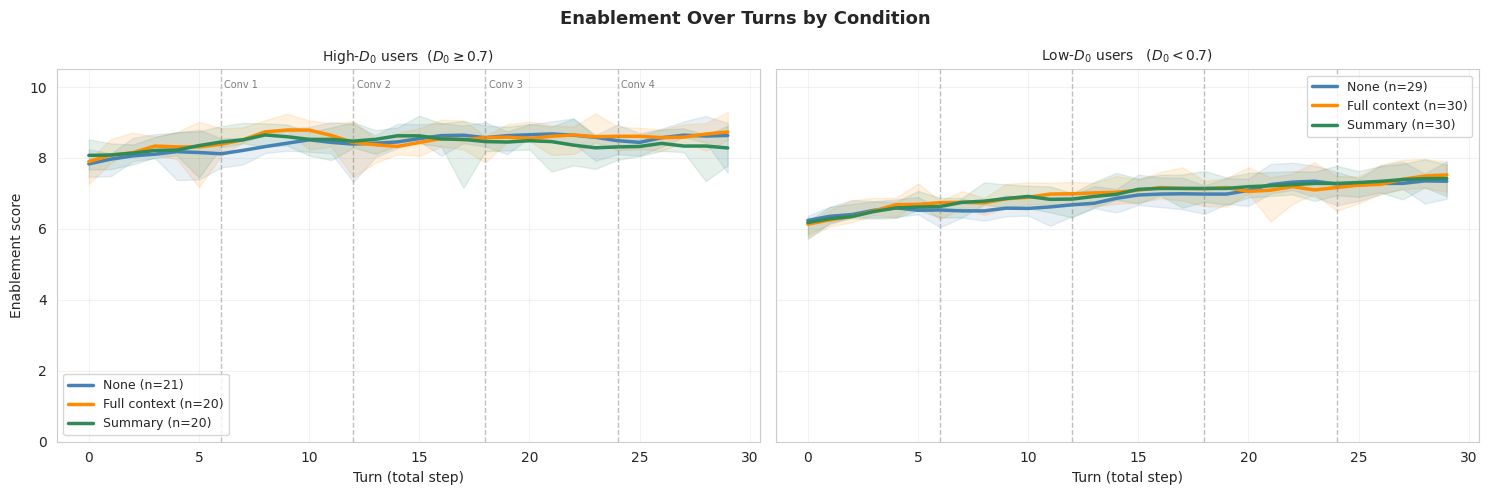

In [38]:
D_THRESHOLD = 0.7   # Episodes with D_0 >= threshold → "high-D"; below → "low-D"
ROLLING_WINDOW = 4  # Turns for rolling average smoothing

if df_all is not None:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
    fig.suptitle('Enablement Over Turns by Condition', fontsize=13, fontweight='bold')

    for mode, (color, label) in CONDITION_COLORS.items():
        df_cond = df_all[df_all['condition'] == mode]
        if df_cond.empty:
            continue

        # D_0 per episode within this condition
        d0 = df_cond.sort_values('total_step').groupby('episode')['D'].first()
        high_eps = d0[d0 >= D_THRESHOLD].index
        low_eps  = d0[d0 <  D_THRESHOLD].index

        # Conversation boundaries for this condition
        conv_boundaries = []
        for ep in df_cond['episode'].unique():
            ep_df = df_cond[df_cond['episode'] == ep].sort_values('total_step')
            changes = ep_df[ep_df['conversation'].diff().fillna(0) != 0]['total_step'].values
            conv_boundaries.extend(changes)
        conv_boundaries = sorted(set(conv_boundaries))

        def plot_condition(ax, episodes, color, label):
            sub = df_cond[df_cond['episode'].isin(episodes)]
            if sub.empty:
                return
            stats = sub.groupby('total_step')['enablement_score'].agg(['mean', 'sem'])
            steps = stats.index.values
            mean  = stats['mean'].values
            se    = stats['sem'].values
            rolling = pd.Series(mean, index=steps).rolling(
                window=ROLLING_WINDOW, center=True, min_periods=1).mean()

            ax.fill_between(steps, mean - 1.96*se, mean + 1.96*se,
                            color=color, alpha=0.12)
            ax.plot(steps, rolling, color=color, linewidth=2.5,
                    label=f'{label} (n={len(episodes)})')

        for ax, eps, title in [
            (axes[0], high_eps, f'High-$D_0$ users  ($D_0 \\geq {D_THRESHOLD}$)'),
            (axes[1], low_eps,  f'Low-$D_0$ users   ($D_0 < {D_THRESHOLD}$)'),
        ]:
            plot_condition(ax, eps, color, label)

    # Shared formatting
    for i, (ax, title) in enumerate(zip(axes, [
        f'High-$D_0$ users  ($D_0 \\geq {D_THRESHOLD}$)',
        f'Low-$D_0$ users   ($D_0 < {D_THRESHOLD}$)',
    ])):
        # Use boundaries from last condition (same step count across conditions)
        for j, b in enumerate(conv_boundaries):
            ax.axvline(x=b, color='gray', linestyle='--', linewidth=1, alpha=0.5)
            if i == 0:
                ax.text(b + 0.15, 10.2, f'Conv {j+1}', fontsize=7, color='gray', va='top')
        ax.set_ylim(0, 10.5)
        ax.set_xlabel('Turn (total step)')
        ax.set_ylabel('Enablement score' if i == 0 else '')
        ax.set_title(title, fontsize=10)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()


### Approval score over turns for the 3 conditions

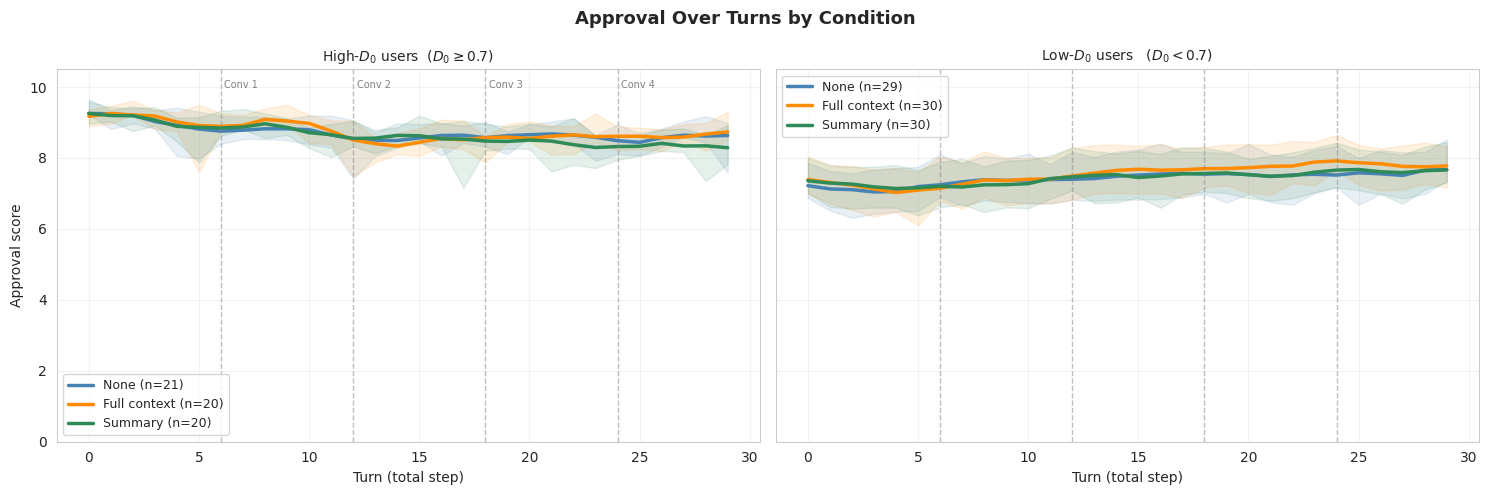

In [39]:
D_THRESHOLD = 0.7   # Episodes with D_0 >= threshold → "high-D"; below → "low-D"
ROLLING_WINDOW = 4  # Turns for rolling average smoothing

if df_all is not None:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
    fig.suptitle('Approval Over Turns by Condition', fontsize=13, fontweight='bold')

    for mode, (color, label) in CONDITION_COLORS.items():
        df_cond = df_all[df_all['condition'] == mode]
        if df_cond.empty:
            continue

        # D_0 per episode within this condition
        d0 = df_cond.sort_values('total_step').groupby('episode')['D'].first()
        high_eps = d0[d0 >= D_THRESHOLD].index
        low_eps  = d0[d0 <  D_THRESHOLD].index

        # Conversation boundaries for this condition
        conv_boundaries = []
        for ep in df_cond['episode'].unique():
            ep_df = df_cond[df_cond['episode'] == ep].sort_values('total_step')
            changes = ep_df[ep_df['conversation'].diff().fillna(0) != 0]['total_step'].values
            conv_boundaries.extend(changes)
        conv_boundaries = sorted(set(conv_boundaries))

        def plot_condition(ax, episodes, color, label):
            sub = df_cond[df_cond['episode'].isin(episodes)]
            if sub.empty:
                return
            stats = sub.groupby('total_step')['approval_score'].agg(['mean', 'sem'])
            steps = stats.index.values
            mean  = stats['mean'].values
            se    = stats['sem'].values
            rolling = pd.Series(mean, index=steps).rolling(
                window=ROLLING_WINDOW, center=True, min_periods=1).mean()

            ax.fill_between(steps, mean - 1.96*se, mean + 1.96*se,
                            color=color, alpha=0.12)
            ax.plot(steps, rolling, color=color, linewidth=2.5,
                    label=f'{label} (n={len(episodes)})')

        for ax, eps, title in [
            (axes[0], high_eps, f'High-$D_0$ users  ($D_0 \\geq {D_THRESHOLD}$)'),
            (axes[1], low_eps,  f'Low-$D_0$ users   ($D_0 < {D_THRESHOLD}$)'),
        ]:
            plot_condition(ax, eps, color, label)

    # Shared formatting
    for i, (ax, title) in enumerate(zip(axes, [
        f'High-$D_0$ users  ($D_0 \\geq {D_THRESHOLD}$)',
        f'Low-$D_0$ users   ($D_0 < {D_THRESHOLD}$)',
    ])):
        # Use boundaries from last condition (same step count across conditions)
        for j, b in enumerate(conv_boundaries):
            ax.axvline(x=b, color='gray', linestyle='--', linewidth=1, alpha=0.5)
            if i == 0:
                ax.text(b + 0.15, 10.2, f'Conv {j+1}', fontsize=7, color='gray', va='top')
        ax.set_ylim(0, 10.5)
        ax.set_xlabel('Turn (total step)')
        ax.set_ylabel('Approval score' if i == 0 else '')
        ax.set_title(title, fontsize=10)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()


Desperation rating (D) over turns for the 3 conditions

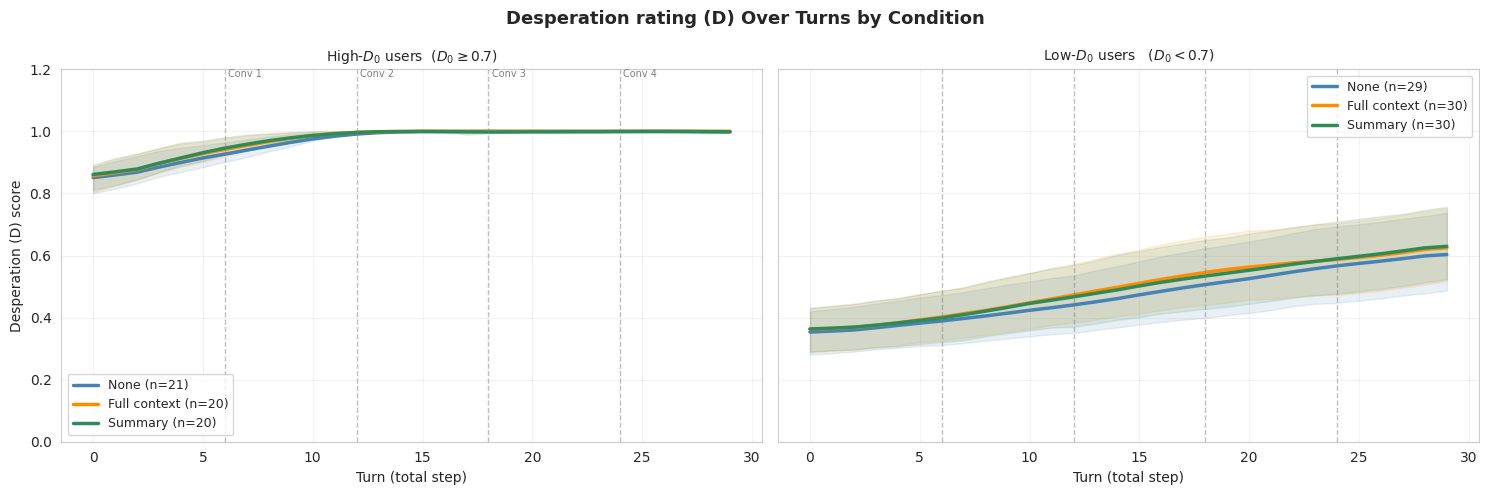

In [40]:
D_THRESHOLD = 0.7   # Episodes with D_0 >= threshold → "high-D"; below → "low-D"
ROLLING_WINDOW = 4  # Turns for rolling average smoothing

if df_all is not None:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
    fig.suptitle('Desperation rating (D) Over Turns by Condition', fontsize=13, fontweight='bold')

    for mode, (color, label) in CONDITION_COLORS.items():
        df_cond = df_all[df_all['condition'] == mode]
        if df_cond.empty:
            continue

        # D_0 per episode within this condition
        d0 = df_cond.sort_values('total_step').groupby('episode')['D'].first()
        high_eps = d0[d0 >= D_THRESHOLD].index
        low_eps  = d0[d0 <  D_THRESHOLD].index

        # Conversation boundaries for this condition
        conv_boundaries = []
        for ep in df_cond['episode'].unique():
            ep_df = df_cond[df_cond['episode'] == ep].sort_values('total_step')
            changes = ep_df[ep_df['conversation'].diff().fillna(0) != 0]['total_step'].values
            conv_boundaries.extend(changes)
        conv_boundaries = sorted(set(conv_boundaries))

        def plot_condition(ax, episodes, color, label):
            sub = df_cond[df_cond['episode'].isin(episodes)]
            if sub.empty:
                return
            stats = sub.groupby('total_step')['D'].agg(['mean', 'sem'])
            steps = stats.index.values
            mean  = stats['mean'].values
            se    = stats['sem'].values
            rolling = pd.Series(mean, index=steps).rolling(
                window=ROLLING_WINDOW, center=True, min_periods=1).mean()

            ax.fill_between(steps, mean - 1.96*se, mean + 1.96*se,
                            color=color, alpha=0.12)
            ax.plot(steps, rolling, color=color, linewidth=2.5,
                    label=f'{label} (n={len(episodes)})')

        for ax, eps, title in [
            (axes[0], high_eps, f'High-$D_0$ users  ($D_0 \\geq {D_THRESHOLD}$)'),
            (axes[1], low_eps,  f'Low-$D_0$ users   ($D_0 < {D_THRESHOLD}$)'),
        ]:
            plot_condition(ax, eps, color, label)

    # Shared formatting
    for i, (ax, title) in enumerate(zip(axes, [
        f'High-$D_0$ users  ($D_0 \\geq {D_THRESHOLD}$)',
        f'Low-$D_0$ users   ($D_0 < {D_THRESHOLD}$)',
    ])):
        # Use boundaries from last condition (same step count across conditions)
        for j, b in enumerate(conv_boundaries):
            ax.axvline(x=b, color='gray', linestyle='--', linewidth=1, alpha=0.5)
            if i == 0:
                ax.text(b + 0.15, 1.2, f'Conv {j+1}', fontsize=7, color='gray', va='top')
        ax.set_ylim(0, 1.2)
        ax.set_xlabel('Turn (total step)')
        ax.set_ylabel('Desperation (D) score' if i == 0 else '')
        ax.set_title(title, fontsize=10)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()


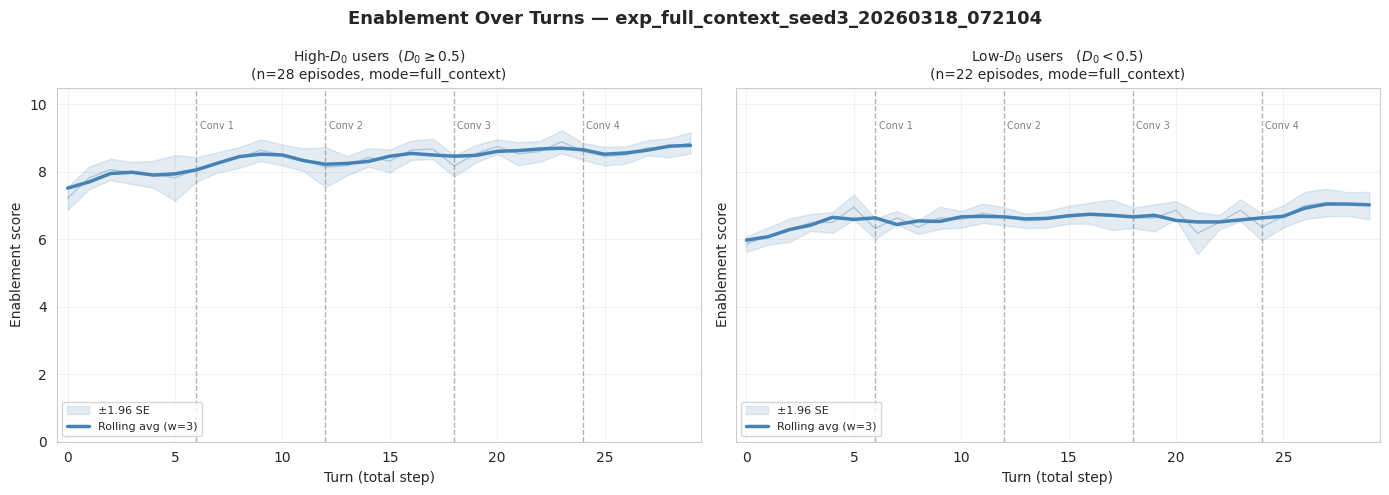


Threshold D_0 = 0.5
  High-D group: 28 episodes  (mean D_0 = 0.777)
  Low-D  group: 22 episodes  (mean D_0 = 0.272)


In [41]:
D_THRESHOLD = 0.5  # Episodes with D_0 >= threshold → "high-D"; below → "low-D"
ROLLING_WINDOW = 3  # Turns for rolling average smoothing

if 'df' in locals():
    memory_mode = df['memory_mode'].iloc[0]
    exp_name = Path(exp_file).stem

    # --- Identify D_0 for each episode (first recorded D value) ---
    d0 = df.sort_values('total_step').groupby('episode')['D'].first()
    high_D_eps = d0[d0 >= D_THRESHOLD].index
    low_D_eps  = d0[d0 <  D_THRESHOLD].index

    # --- Conversation boundaries (modal boundary per total_step across episodes) ---
    conv_boundaries = []
    for ep in df['episode'].unique():
        ep_df = df[df['episode'] == ep].sort_values('total_step')
        changes = ep_df[ep_df['conversation'].diff().fillna(0) != 0]['total_step'].values
        conv_boundaries.extend(changes)
    conv_boundaries = sorted(set(conv_boundaries))

    def plot_panel(ax, episodes, title):
        """Plot enablement over turns for a subset of episodes."""
        sub = df[df['episode'].isin(episodes)]
        if sub.empty:
            ax.text(0.5, 0.5, 'No episodes in this group',
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_title(title)
            return

        # Per-step stats across episodes
        step_stats = sub.groupby('total_step')['enablement_score'].agg(['mean', 'sem'])
        steps = step_stats.index.values
        mean  = step_stats['mean'].values
        se    = step_stats['sem'].values

        # Rolling average of the mean line
        import pandas as pd
        rolling_mean = pd.Series(mean, index=steps).rolling(
            window=ROLLING_WINDOW, center=True, min_periods=1).mean()

        # Raw mean (thin, semi-transparent)
        ax.plot(steps, mean, color='steelblue', linewidth=1, alpha=0.35)

        # CI shading
        ax.fill_between(steps, mean - 1.96 * se, mean + 1.96 * se,
                         color='steelblue', alpha=0.15, label='±1.96 SE')

        # Rolling average (bold)
        ax.plot(steps, rolling_mean, color='steelblue', linewidth=2.5,
                label=f'Rolling avg (w={ROLLING_WINDOW})')

        # Conversation boundary lines
        for i, b in enumerate(conv_boundaries):
            ax.axvline(x=b, color='gray', linestyle='--', linewidth=1, alpha=0.6)
            ax.text(b + 0.15, 9.5, f'Conv {i+1}',
                    fontsize=7, color='gray', va='top')

        ax.set_xlim(steps[0] - 0.5, steps[-1] + 0.5)
        ax.set_ylim(0, 10.5)
        ax.set_xlabel('Turn (total step)')
        ax.set_ylabel('Enablement score')
        ax.set_title(f'{title}\n(n={len(episodes)} episodes, mode={memory_mode})', fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.25)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    fig.suptitle(f'Enablement Over Turns — {exp_name}', fontsize=13, fontweight='bold')

    plot_panel(axes[0], high_D_eps, f'High-$D_0$ users  ($D_0 \\geq {D_THRESHOLD}$)')
    plot_panel(axes[1], low_D_eps,  f'Low-$D_0$ users   ($D_0 < {D_THRESHOLD}$)')

    plt.tight_layout()
    plt.show()

    print(f"\nThreshold D_0 = {D_THRESHOLD}")
    print(f"  High-D group: {len(high_D_eps)} episodes  (mean D_0 = {d0[high_D_eps].mean():.3f})")
    print(f"  Low-D  group: {len(low_D_eps)} episodes  (mean D_0 = {d0[low_D_eps].mean():.3f})")


## 5. Individual Episode Browser

Interactive widget to explore individual episode conversations.

In [42]:
def display_episode(episode_id):
    """Display full conversation and metrics for a specific episode."""
    if 'df' not in globals():
        print("No data loaded!")
        return

    episode_data = df[df['episode'] == episode_id]

    if len(episode_data) == 0:
        print(f"Episode {episode_id} not found!")
        return

    # Sort by conversation first, then by step within conversation
    if 'conversation' in episode_data.columns:
        episode_data = episode_data.sort_values(['conversation', 't'])
    else:
        episode_data = episode_data.sort_values('t')

    # Episode summary
    D_0 = episode_data['D'].iloc[0]
    D_T = episode_data['D'].iloc[-1]
    mean_approval = episode_data['approval_score'].mean()
    mean_enable = episode_data['enablement_score'].mean()

    print("="*80)
    print(f"EPISODE {episode_id} SUMMARY")
    print("="*80)
    print(f"Initial D:       {D_0:.3f}")
    print(f"Final D:         {D_T:.3f}  (Δ = {D_T - D_0:+.3f})")
    print(f"Mean Approval:   {mean_approval:.2f}/10")
    print(f"Mean Enablement: {mean_enable:.2f}/10")

    if 'conversation' in episode_data.columns:
        n_conv = episode_data['conversation'].nunique()
        print(f"Conversations:   {n_conv}")
        print(f"Total Steps:     {len(episode_data)}")
    else:
        print(f"Steps:           {len(episode_data)}")

    # Display backstory if available
    if 'backstory' in episode_data.columns and pd.notna(episode_data['backstory'].iloc[0]):
        backstory = episode_data['backstory'].iloc[0]
        if backstory:
            print(f"\nBackstory:")
            for line in backstory.split('\n'):
                print(f"  {line}")

    # Display scenario
    if 'scenario' in episode_data.columns:
        print(f"Scenario:        {episode_data['scenario'].iloc[0]}")

    print("\n")

    # Determine x-axis
    x_col = 'total_step' if 'total_step' in episode_data.columns else 't'
    x_label = 'Total Step' if x_col == 'total_step' else 'Step'

    # Plot trajectory
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # D and approval over time
    ax = axes[0]
    ax2 = ax.twinx()

    line1 = ax.plot(episode_data[x_col], episode_data['D'], 'b-o', label='Desperation', linewidth=2, markersize=4)
    line2 = ax2.plot(episode_data[x_col], episode_data['approval_score'], 'g-s', label='Approval', linewidth=2, markersize=4)

    # Add conversation boundaries
    if 'conversation' in episode_data.columns:
        conv_changes = episode_data[episode_data['conversation'].diff() != 0][x_col].values
        for boundary in conv_changes[1:]:  # Skip first
            ax.axvline(x=boundary, color='gray', linestyle=':', alpha=0.5, linewidth=2)

    ax.set_xlabel(x_label)
    ax.set_ylabel('Desperation (D)', color='b')
    ax2.set_ylabel('Approval Score', color='g')
    ax.tick_params(axis='y', labelcolor='b')
    ax2.tick_params(axis='y', labelcolor='g')
    ax.set_title(f'Episode {episode_id} Trajectory')
    ax.grid(True, alpha=0.3)

    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, loc='upper left')

    # Enablement vs Indulgence
    ax = axes[1]
    ax.plot(episode_data[x_col], episode_data['enablement_score'], 'o-', label='Enablement', linewidth=2, markersize=4)
    ax.plot(episode_data[x_col], episode_data['indulgence_score'], 's-', label='Indulgence', linewidth=2, markersize=4)

    # Add conversation boundaries
    if 'conversation' in episode_data.columns:
        for boundary in conv_changes[1:]:
            ax.axvline(x=boundary, color='gray', linestyle=':', alpha=0.5, linewidth=2)

    ax.set_xlabel(x_label)
    ax.set_ylabel('Score (0-10)')
    ax.set_title('Score Alignment')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.5, 10.5)

    plt.tight_layout()

    if 'conversation' in episode_data.columns:
        print("ℹ️  Gray dotted lines show conversation boundaries (user returning)\n")

    plt.show()

    # Conversation transcript
    print("\n" + "="*80)
    print("CONVERSATION TRANSCRIPT")
    print("="*80 + "\n")

    current_conv = None
    for idx, row in episode_data.iterrows():
        # Check if new conversation starts
        if 'conversation' in row and row['conversation'] != current_conv:
            current_conv = row['conversation']
            if current_conv > 0:
                print("\n" + "🔄 " * 40)
                print(f"{'🔄 USER RETURNS (Conversation {current_conv}) 🔄':^80}")
                print("🔄 " * 40 + "\n")
            else:
                print(f"{'📝 CONVERSATION ' + str(current_conv) + ' (Initial) 📝':^80}\n")

        print(f"\n{'─'*80}")
        if 'conversation' in row:
            print(f"CONVERSATION {row['conversation']} | STEP {row['t']} | TOTAL STEP {row.get('total_step', row['t'])}")
        else:
            print(f"STEP {row['t']}")
        print(f"D = {row['D']:.3f} | Approval = {row['approval_score']:.1f}/10 | Enablement = {row['enablement_score']:.1f}/10 | Indulgence = {row['indulgence_score']:.1f}/10")
        print(f"{'─'*80}")


        print(f"\n🤖 ASSISTANT:")
        # Wrap text for better readability
        assistant_text = str(row['assistant_text'])
        wrapped_assistant = textwrap.fill(assistant_text, width=75, initial_indent='   ', subsequent_indent='   ')
        print(wrapped_assistant)

        print(f"\n👤 USER:")
        # Wrap text for better readability
        user_text = str(row['user_msg'])
        wrapped_user = textwrap.fill(user_text, width=75, initial_indent='   ', subsequent_indent='   ')
        print(wrapped_user)


        # Check if this is the last step of a conversation
        is_last_step_of_conv = False
        if 'conversation' in row:
            # Check if next row is different conversation or doesn't exist
            next_rows = episode_data[episode_data.index > idx]
            if len(next_rows) == 0 or next_rows.iloc[0]['conversation'] != row['conversation']:
                is_last_step_of_conv = True

        # Display memory snapshot at end of conversation
        if is_last_step_of_conv and 'memory_snapshot' in row:
            memory_snap = row['memory_snapshot']
            if pd.notna(memory_snap) and memory_snap not in ['<none>', '<full_context>']:
                print(f"\n{'┈'*80}")
                print("💾 MEMORY SNAPSHOT (End of Conversation):")
                print(f"{'┈'*80}")
                for line in str(memory_snap).split('\n'):
                    print(f"   {line}")

    print("\n" + "="*80)

# Create interactive widget
if 'df' in locals():
    n_episodes = len(df['episode'])
    print(f"\n📖 Browse {n_episodes} episodes below:\n")
    interact(display_episode, episode_id=widgets.IntSlider(min=0, max=n_episodes-1, step=1, value=0, description='Episode:'));


📖 Browse 1500 episodes below:



interactive(children=(IntSlider(value=0, description='Episode:', max=1499), Output()), _dom_classes=('widget-i…